# Preparation step

In [1]:
import pandas as pd

cycling = pd.read_csv("../datasets/bike_rides.csv", index_col=0,
                      parse_dates=True)
cycling.index.name = ""
target_name = "power"
data, target = cycling.drop(columns=target_name), cycling[target_name]
data

,heart-rate,cadence,speed,acceleration,slope
,,,,,
2020-08-18 14:43:19,102.0,64.0,4.325,0.0880,-0.033870
2020-08-18 14:43:20,103.0,64.0,4.336,0.0842,-0.033571
2020-08-18 14:43:21,105.0,66.0,4.409,0.0234,-0.033223
2020-08-18 14:43:22,106.0,66.0,4.445,0.0016,-0.032908
2020-08-18 14:43:23,106.0,67.0,4.441,0.1144,0.000000
...,...,...,...,...,...
2020-09-13 14:55:57,130.0,0.0,1.054,0.0234,0.000000
2020-09-13 14:55:58,130.0,0.0,0.829,0.0258,0.000000
2020-09-13 14:55:59,129.0,0.0,0.616,-0.1686,0.000000


**a) create a new data matrix data_linear_model containing the cube of the speed, the speed, the speed multiplied by the sine of the angle of the slope, and the speed multiplied by the acceleration. To compute the angle of the slope, you need to take the arc tangent of the slope (alpha = np.arctan(slope)). In addition, we can limit ourself to positive acceleration only by clipping to 0 the negative acceleration values (they would correspond to some power created by the braking that we are not modeling here).**

In [2]:
# Ignore deceleration
data_no_deceleration = data.copy()
data_no_deceleration["acceleration"] = data_no_deceleration["acceleration"].clip(lower=0)

In [3]:
import numpy as np

data_linear_model = pd.DataFrame() 
data_linear_model.insert(0, "V^3", data_no_deceleration["speed"]**3) 
data_linear_model.insert(0, "V*sin(α)", data_no_deceleration["speed"]*np.sin(np.arctan(data_no_deceleration["slope"])))
data_linear_model.insert(0, "V*a", data_no_deceleration["speed"]*data["acceleration"]) 
data_linear_model.insert(0, "V", data_no_deceleration["speed"])

In [4]:
data_linear_model

,V,V*a,V*sin(α),V^3
,,,,
2020-08-18 14:43:19,4.325,0.380600,-0.146402,80.901828
2020-08-18 14:43:20,4.336,0.365091,-0.145482,81.520685
2020-08-18 14:43:21,4.409,0.103171,-0.146398,85.707790
2020-08-18 14:43:22,4.445,0.007112,-0.146198,87.824421
2020-08-18 14:43:23,4.441,0.508050,0.000000,87.587538
...,...,...,...,...
2020-09-13 14:55:57,1.054,0.024664,0.000000,1.170905
2020-09-13 14:55:58,0.829,0.021388,0.000000,0.569723
2020-09-13 14:55:59,0.616,-0.103858,0.000000,0.233745


**b) using the new data matrix, create a linear predictive model based on a sklearn.preprocessing.StandardScaler and a sklearn.linear_model.RidgeCV;**

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(),
    RidgeCV()
)

**c) use a sklearn.model_selection.ShuffleSplit cross-validation strategy with only 4 splits (n_splits=4) to evaluate the generalization performance of the model. Use the mean absolute error (MAE) as a generalization performance metric. Also, pass the parameter return_estimator=True and return_train_score=True to answer the subsequent questions. Be aware that the ShuffleSplit strategy is a naive strategy and we will investigate the consequence of making this choice in the subsequent questions.**

In [6]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate

cv_results_SS = cross_validate(
    pipeline,
    data_linear_model,
    target,
    cv=ShuffleSplit(n_splits=4),
    scoring="neg_mean_absolute_error",
    return_estimator=True,
    return_train_score=True
)

# Q1

In [7]:
data_linear_model['V*sin(α)'].mean()

np.float64(-0.0027097096125663256)

# Q2

In [8]:
cv_results_SS

{'fit_time': array([0.01504183, 0.01272988, 0.01268506, 0.01193953]),
 'score_time': array([0.00161076, 0.00169587, 0.00156784, 0.00166392]),
 'estimator': [Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())])],
 'test_score': array([-72.18052441, -71.37253283, -71.70210708, -72.44622015]),
 'train_score': array([-72.3584456 , -72.4250768 , -72.44063001, -72.34315413])}

# Q3

In [9]:
for model in cv_results_SS['estimator']:
    print(model[1].coef_)

[32.31983985 13.20548187 78.31080297  4.93903844]
[33.02058248 13.09760471 78.05327559  4.29909574]
[32.7991313  13.63043973 78.53633096  4.3993137 ]
[33.26436188 13.5174324  78.14975915  3.99308111]


# Q4

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_hgbr = HistGradientBoostingRegressor(max_iter=1000, early_stopping=True)
cv_results_hgbr = cross_validate(
    model_hgbr,
    data,
    target,
    cv=ShuffleSplit(n_splits=4),
    scoring="neg_mean_absolute_error",
    return_estimator=True,
    return_train_score=True
)

cv_results_hgbr

{'fit_time': array([1.81352544, 0.37282133, 0.28920722, 0.380862  ]),
 'score_time': array([0.01377416, 0.01122212, 0.00847816, 0.0116787 ]),
 'estimator': [HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000)],
 'test_score': array([-44.8463158 , -43.92415803, -44.66236371, -44.24255065]),
 'train_score': array([-39.63817334, -40.5212376 , -41.36385298, -40.36125404])}

# Q5

In [11]:
cv_results_SS

{'fit_time': array([0.01504183, 0.01272988, 0.01268506, 0.01193953]),
 'score_time': array([0.00161076, 0.00169587, 0.00156784, 0.00166392]),
 'estimator': [Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())]),
  Pipeline(steps=[('standardscaler', StandardScaler()), ('ridgecv', RidgeCV())])],
 'test_score': array([-72.18052441, -71.37253283, -71.70210708, -72.44622015]),
 'train_score': array([-72.3584456 , -72.4250768 , -72.44063001, -72.34315413])}

In [12]:
cv_results_hgbr

{'fit_time': array([1.81352544, 0.37282133, 0.28920722, 0.380862  ]),
 'score_time': array([0.01377416, 0.01122212, 0.00847816, 0.0116787 ]),
 'estimator': [HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000),
  HistGradientBoostingRegressor(early_stopping=True, max_iter=1000)],
 'test_score': array([-44.8463158 , -43.92415803, -44.66236371, -44.24255065]),
 'train_score': array([-39.63817334, -40.5212376 , -41.36385298, -40.36125404])}

# Q6

In [13]:
pd.DataFrame(data.index.date).value_counts()

0         
2020-08-26    10324
2020-08-18    10222
2020-08-20    10055
2020-09-13     7653
Name: count, dtype: int64

# Q7

**a) create a variable called group that is a 1D numpy array containing the index of each ride present in the dataframe. Therefore, the length of group will be equal to the number of samples in data. If we had 2 bike rides, we would expect the indices 0 and 1 in group to differentiate the bike ride. You can use pd.factorize to encode any Python types into integer indices.**\
**b) create a cross-validation object named cv using the sklearn.model_selection.LeaveOneGroupOut strategy.**\

In [14]:
data_LOGO = data
group = pd.factorize(data_LOGO.index.date) # a)
group = group[0]

from sklearn.model_selection import LeaveOneGroupOut # b)
cv = LeaveOneGroupOut()

**c) evaluate both the linear and histogram gradient boosting models with this strategy.**

In [15]:
cv_lr_LOGO_results = cross_validate(
    pipeline,
    data_linear_model,
    target,
    cv=cv,
    groups=group,
    scoring="neg_mean_absolute_error",
    return_train_score=True
)
cv_hgbr_LOGO_results = cross_validate(
    model_hgbr,
    data,
    target,
    cv=cv,
    groups=group,
    scoring="neg_mean_absolute_error",
    return_train_score=True
)

In [16]:
cv_lr_LOGO_results

{'fit_time': array([0.01470947, 0.01279283, 0.01084208, 0.0130167 ]),
 'score_time': array([0.0018959 , 0.00171065, 0.00173283, 0.00183463]),
 'test_score': array([-72.25109313, -73.30180058, -81.1825154 , -64.73407571]),
 'train_score': array([-72.375695  , -72.1440918 , -68.87831703, -75.0173272 ])}

In [17]:
cv_hgbr_LOGO_results

{'fit_time': array([0.32583475, 0.55395341, 0.43660688, 0.31528115]),
 'score_time': array([0.02029157, 0.0344491 , 0.02590203, 0.01696229]),
 'test_score': array([-47.53103843, -48.35481384, -54.21315036, -47.06528926]),
 'train_score': array([-40.59775518, -38.08928939, -37.35509926, -42.09334602])}

# Q8

In [18]:
-cv_lr_LOGO_results['test_score'].mean() ### Lr LeaveOneGroupOut

np.float64(72.86737120611252)

In [20]:
-cv_results_SS['test_score'].mean() ### Lr Shuffle Split

np.float64(71.9253461164754)

# Q9

In [21]:
-cv_hgbr_LOGO_results['test_score'].mean()

np.float64(49.29107297467627)

In [22]:
-cv_results_hgbr['test_score'].mean()

np.float64(44.418847047909836)

# Q10

In [33]:
cv_lr_LOGO_results['test_score'].std()

np.float64(5.827963755218926)

In [34]:
cv_lr_LOGO_results['train_score'].std()

np.float64(2.1776094381968347)

In [35]:
cv_hgbr_LOGO_results['test_score'].std()

np.float64(2.8790302937941323)

In [36]:
cv_hgbr_LOGO_results['train_score'].std()

np.float64(1.905034400072039)

In [37]:
cv_results_SS['test_score'].std()

np.float64(0.4158917885386337)

In [38]:
cv_results_SS['train_score'].std()

np.float64(0.04174520647629767)

In [39]:
cv_results_hgbr['test_score'].std()

np.float64(0.3598011761144768)

In [40]:
cv_results_hgbr['train_score'].std()

np.float64(0.6134644662270355)

# Q11

In [42]:
cv = LeaveOneGroupOut()
train_indices, test_indices = list(cv.split(data, target, groups=group))[0]

data_linear_model_train = data_linear_model.iloc[train_indices]
data_linear_model_test = data_linear_model.iloc[test_indices]

data_train = data.iloc[train_indices]
data_test = data.iloc[test_indices]

target_train = target.iloc[train_indices]
target_test = target.iloc[test_indices]

In [45]:
pipeline.fit(data_train, target_train)
model_hgbr.fit(data_train, target_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,1000
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [46]:
y_predict_lr = pipeline.predict(data_test)
y_predict_hgbr = model_hgbr.predict(data_test)

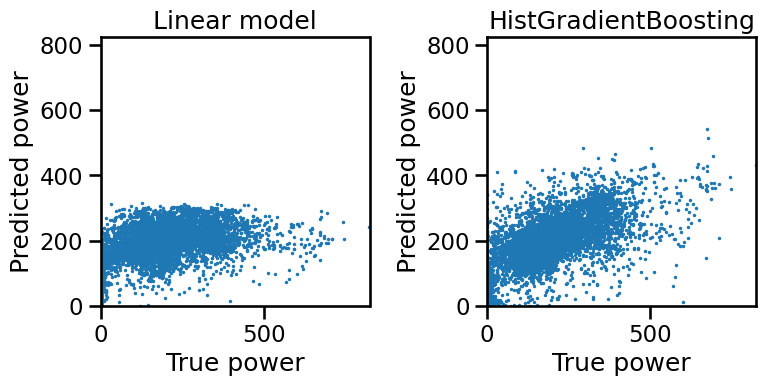

In [69]:
import matplotlib.pyplot as plt

y_true = target_test


fig, ax = plt.subplots(1, 2, figsize=(8, 4))

xmax = max(y_true.max(), y_predict_lr.max(), y_predict_hgbr.max())

# Linear model
ax[0].scatter(y_true, y_predict_lr, s=1)
ax[0].set_title("Linear model")
ax[0].set_xlabel("True power")
ax[0].set_ylabel("Predicted power")
ax[0].set_xlim(0, xmax)
ax[0].set_ylim(0, xmax)
ax[0].set_aspect('equal', 'box')  # make it square

# HGBR model
ax[1].scatter(y_true, y_predict_hgbr, s=1)
ax[1].set_title("HistGradientBoosting")
ax[1].set_xlabel("True power")
ax[1].set_ylabel("Predicted power")
ax[1].set_xlim(0, xmax)
ax[1].set_ylim(0, xmax)
ax[1].set_aspect('equal', 'box')  # make it square

plt.tight_layout()
plt.show()

# Q12

In [70]:
time_slice = slice("2020-08-18 17:00:00", "2020-08-18 17:05:00")

data_test_linear_model_subset = data_linear_model_test[time_slice]
data_test_subset = data_test[time_slice]
target_test_subset = target_test[time_slice]

In [73]:
y_pred_lr_12 = pipeline.predict(data_test_subset )
y_pred_hgbr_12 = model_hgbr.predict(data_test_subset)

y_true_12 = target_test_subset

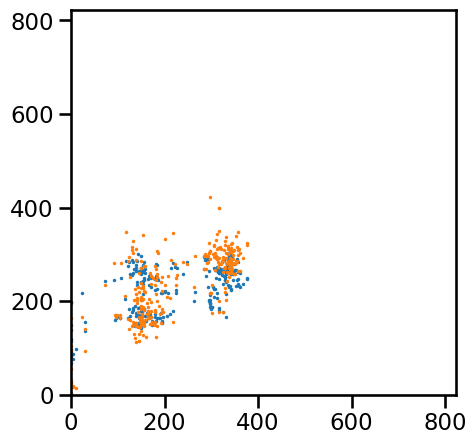

In [87]:
fig, ax = plt.subplots(1, figsize=(8, 5))
xmax = max(y_true.max(), y_predict_lr.max(), y_predict_hgbr.max())

plt.scatter(y_true_12, y_pred_lr_12, s=1)
plt.scatter(y_true_12, y_pred_hgbr_12, s=1)

ax.set_xlim(0, xmax)
ax.set_ylim(0, xmax)
ax.set_aspect('equal', 'box')  # make it square

# Remarks - ???